# Two-Dimensional Ising Model

This tutorial demonstrates how to use `jaxfss` with **Flax NNX** to perform **Neural Scaling Analysis (NSA)** on the two-dimensional ferromagnetic Ising model on a square lattice.


## 1. Theoretical Background

The Binder ratio $U(T, L)$ is a dimensionless quantity defined by fourth- and second-order magnetization moments:

$$
U(T, L) = 1 - \frac{\langle M^4 \rangle}{3 \langle M^2 \rangle^2}
$$

Because $U(T, L)$ is dimensionless, its critical exponent $c_2$ is zero ($c_2 = 0$). The finite-size scaling hypothesis reads:

$$
U(T, L) = F\left[ (T - T_{\mathrm{c}}) L^{c_1} \right]
$$

where:
* $1/T_{\mathrm{c}} = \frac{1}{2}\ln(1+\sqrt{2}) \approx 0.4406868$ (exact critical inverse temperature for square lattice).
* $c_1 = 1/\nu = 1.0$ (exact correlation length exponent).
* $F[\cdot]$ is the unknown universal scaling function.

## 2. Load and Inspect Data

We use `CriticalData` to load the dataset (`data/ising.txt`).

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
import optax
from softclip import SoftClip

import jaxfss

# Load Monte Carlo simulation data
dataset = jaxfss.CriticalData.from_file("data/ising.txt")
print(f"Loaded {dataset.n_data} data points.")
print(f"System sizes: {jnp.unique(dataset.Ls)}")

Loaded 86 data points.
System sizes: [ 64. 128. 256.]


Visualize the raw Binder ratio data.

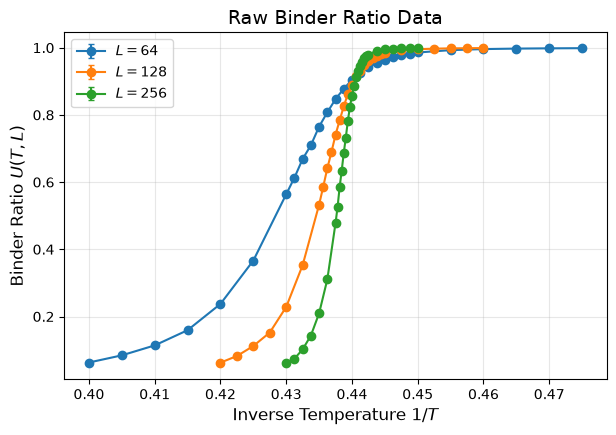

In [2]:
plt.figure(figsize=(7, 4.5))
unique_Ls = sorted(list(set(dataset.Ls.flatten().tolist())))
for L in unique_Ls:
    idx = dataset.Ls.flatten() == L
    plt.errorbar(
        dataset.Ts.flatten()[idx],
        dataset.As.flatten()[idx],
        yerr=dataset.As_err.flatten()[idx],
        fmt="o-",
        label=f"$L = {int(L)}$",
        capsize=2
    )

plt.xlabel(r"Inverse Temperature $1/T$", fontsize=12)
plt.ylabel(r"Binder Ratio $U(T, L)$", fontsize=12)
plt.title("Raw Binder Ratio Data", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Set Up NNX Scaling Model

We construct a `FSSModel` wrapping a `RationalMLP` scaling function and parameter bijectors:
* $c_1 > 0$ via `SoftClip(low=0.0)`
* Scaled $T_{\mathrm{c}} \in [-1, 1]$ via `SoftClip(low=-1.0, high=1.0)`

In [3]:
bij_c1 = SoftClip(low=0.0)
bij_Tc = SoftClip(low=-1.0, high=1.0)

def bijector(p):
    p1, pc = p
    return jnp.array([bij_c1.forward(p1), bij_Tc.forward(pc)])

scaling_fn = jaxfss.RationalMLP(din=1, features=[20, 20, 1], rngs=nnx.Rngs(42))
model = jaxfss.FSSModel(scaling_fn=scaling_fn, n_critical=2, bijector=bijector)

train_data = dataset.train_data
Ls = train_data["system_size"]
Ts = train_data["temperature"]
As = train_data["observable"]
vAs = train_data["observable_var"]

def loss_fn(m: jaxfss.FSSModel):
    y_pred = m(Ls, Ts)
    return jaxfss.NLLLoss(As, y_pred, vAs)

## 4. Optimization with NNX

We optimize the NNX model using `jaxfss.fit` with multi-optimizer support.

In [4]:
optimizer = {
    "scaling_fn": optax.adam(learning_rate=1e-3),
    "fss": optax.adam(learning_rate=1e-2)
}
steps = 8000

losses, critical_vals = jaxfss.fit(model, loss_fn, optimizer, steps)

c1_est, scaled_Tc_est = model.critical_params
Tc_est = float(dataset.bij_temperature.inverse(scaled_Tc_est))
c1_est = float(c1_est)

print("=== Estimation Results ===")
print(f"c_1 (exact = 1.0)       : {c1_est:.5f}")
print(f"1/Tc (exact = 0.44069)  : {Tc_est:.5f}")

=== Estimation Results ===
c_1 (exact = 1.0)       : 0.99059
1/Tc (exact = 0.44069)  : 0.44070


## 5. Scaling Collapse and NN Fitting Curve

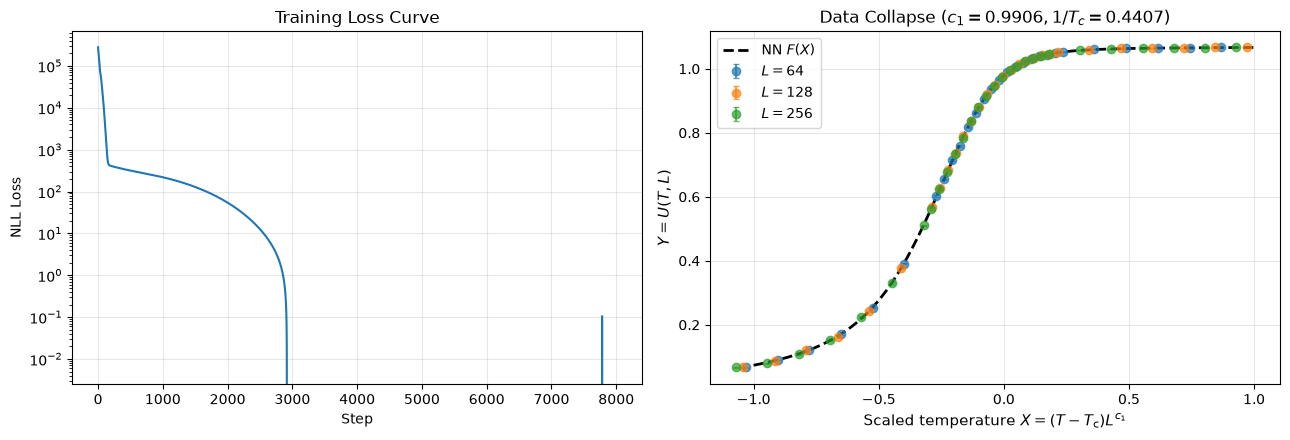

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Loss curve
ax1.plot(losses)
ax1.set_yscale("log")
ax1.set_xlabel("Step")
ax1.set_ylabel("NLL Loss")
ax1.set_title("Training Loss Curve")
ax1.grid(True, alpha=0.3)

# Scaling collapse
for L in unique_Ls:
    idx = dataset.Ls.flatten() == L
    t = Ts.flatten()[idx]
    s = Ls.flatten()[idx]
    x = (t - scaled_Tc_est) * (s ** c1_est)
    y = As.flatten()[idx]
    yerr = jnp.sqrt(vAs.flatten()[idx])
    ax2.errorbar(x, y, yerr=yerr, fmt="o", label=f"$L={int(L)}$", alpha=0.7, capsize=2)

# Plot NN prediction
x_grid = jnp.linspace(-1.0, 1.0, 200).reshape(-1, 1)
y_pred = model.scaling_fn(x_grid)
ax2.plot(x_grid, y_pred, color="black", lw=2, linestyle="--", label="NN $F(X)$")

ax2.set_xlabel(r"Scaled temperature $X = (T - T_{\mathrm{c}}) L^{c_1}$", fontsize=11)
ax2.set_ylabel(r"$Y = U(T, L)$", fontsize=11)
ax2.set_title(f"Data Collapse ($c_1={c1_est:.4f}, 1/T_c={Tc_est:.4f}$)", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()